# Notebook 10 — Projeto final
# Objetivo: fusão NIR+MIR para prever todos os atributos de solo disponíveis.



## Checklist
- [ ] documentar fonte e unidade dos dados
- [ ] controlar qualidade
- [ ] separar treino/teste
- [ ] construir baseline
- [ ] comparar modelos
- [ ] avaliar R², RMSE e MAE
- [ ] analisar resíduos
- [ ] interpretar o modelo
- [ ] discutir limitações e domínio de aplicação


Ignorado OM_gkg: apenas 0 observações válidas.
CHECKLIST DO PROJETO FINAL - FUSÃO NIR + MIR
[OK] Fontes: raw_nir_data_Saturin.csv + raw_mir_data_Saturin.csv
[OK] Alinhamento por ID_Unico: 6230 amostras correspondentes
[OK] Controle de qualidade: 6230 amostras, 3052 bandas (2151 NIR + 901 MIR)
[OK] Separação treino/teste: 80/20 por atributo
[OK] Baseline e PLS comparados
[OK] R2, RMSE e MAE calculados
[OK] Resíduos e previsões completas gerados

Melhor modelo por atributo:


,target,unit,model,n_valid,MAE,RMSE,R2
0,C_gkg,g/kg,PLS,2749,32.6958,51.5638,0.8848
1,pH_H2O,pH,PLS,5696,0.5350,0.7173,0.7500
2,MacroN_g_kg,g/kg,PLS,991,2.7958,4.0518,0.7249
3,Clay_gkg,g/kg,PLS,5541,90.0294,115.9806,0.6956
4,CEC_Ph7_mmolkg,mmol/kg,PLS,3400,56.6365,79.7771,0.6955
5,Ca_mmolkg,mmol/kg,PLS,2980,57.4984,84.4492,0.6719
6,Density_kgdm3,kg/dm3,PLS,1437,0.2015,0.2555,0.6391
7,Sand_gkg,g/kg,PLS,5475,124.0069,161.2239,0.6384
8,Silt_gkg,g/kg,PLS,5526,91.0347,118.3722,0.6072
9,CEC_Efe_mmolkg,mmol/kg,PLS,472,111.0364,180.4534,0.6027



Resumo dos resíduos:


,target,residual_mean,residual_std,residual_mae
0,Sand_gkg,1.7053,161.2148,124.0069
1,Silt_gkg,-3.8148,118.3108,91.0347
2,Clay_gkg,-7.8875,115.7121,90.0294
3,Density_kgdm3,-0.0046,0.2554,0.2015
4,C_gkg,0.5207,51.5611,32.6958
5,P_mgkg,0.5299,22.0861,11.7194
6,pH_H2O,-0.0164,0.7171,0.5350
7,Ca_mmolkg,-1.5176,84.4355,57.4984
8,Mg_mmolkg,-1.3916,38.1990,22.7512
9,K_mmolkg,0.2052,5.9048,3.4555



Prévia das previsões NIR+MIR:


,ID_Unico,Sand_gkg_observed,Sand_gkg_predicted,Sand_gkg_residual,Silt_gkg_observed,Silt_gkg_predicted,Silt_gkg_residual,Clay_gkg_observed,Clay_gkg_predicted,Clay_gkg_residual,...,K_mmolkg_residual,CEC_Ph7_mmolkg_observed,CEC_Ph7_mmolkg_predicted,CEC_Ph7_mmolkg_residual,CEC_Efe_mmolkg_observed,CEC_Efe_mmolkg_predicted,CEC_Efe_mmolkg_residual,MacroN_g_kg_observed,MacroN_g_kg_predicted,MacroN_g_kg_residual
0,1,787.0,632.221228,154.778772,123.0,238.054883,-115.054883,90.0,129.749600,-39.749600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,538.0,460.377332,77.622668,172.0,205.543477,-33.543477,290.0,322.047138,-32.047138,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,255.0,316.050417,-61.050417,295.0,121.354511,173.645489,450.0,507.172621,-57.172621,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,210.0,313.617042,-103.617042,240.0,110.035554,129.964446,550.0,511.544722,38.455278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,236.0,287.381753,-51.381753,234.0,139.599737,94.400263,530.0,517.458873,12.541127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


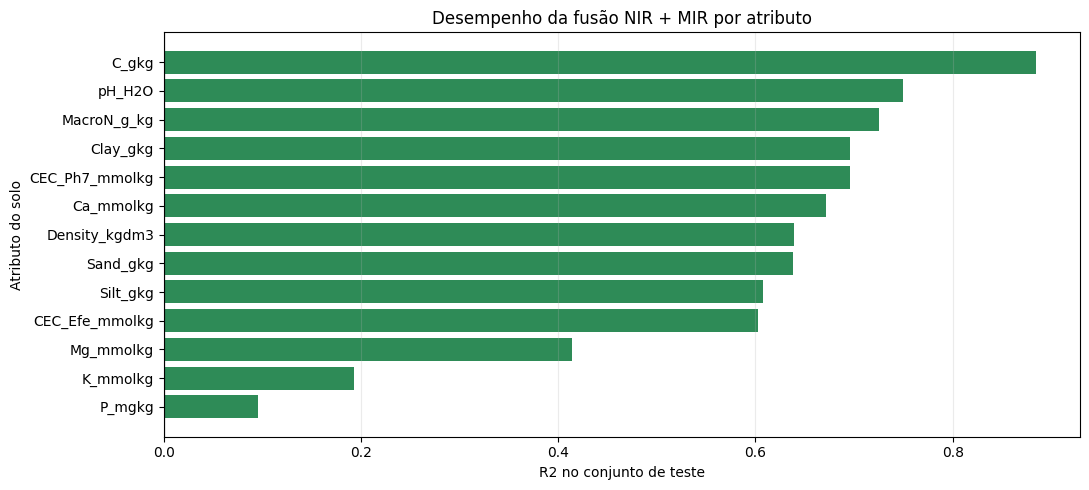

Arquivo de previsões salvo em: predicoes_completas_NIR_MIR.csv


In [4]:
# Pipeline completo: fusão NIR + MIR e previsão de todos os atributos do solo
# Fontes: raw_nir_data_Saturin.csv e raw_mir_data_Saturin.csv
# As bases são alinhadas por ID_Unico; as unidades dos alvos preservam os nomes originais.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
NIR_PATH = DATA_DIR / "raw_nir_data_Saturin.csv"
MIR_PATH = DATA_DIR / "raw_mir_data_Saturin.csv"
for data_path in (NIR_PATH, MIR_PATH):
    if not data_path.exists():
        raise FileNotFoundError(f"Base de dados não encontrada: {data_path}")


def read_csv_robust(data_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(data_path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível decodificar {data_path.name}")


def find_spectral_columns(frame):
    columns = []
    for column in frame.columns:
        try:
            wavelength = float(str(column).strip().replace(",", "."))
        except (TypeError, ValueError):
            continue
        if 300 <= wavelength <= 4000:
            columns.append(column)
    return sorted(columns, key=lambda column: float(str(column).replace(",", ".")))


nir = read_csv_robust(NIR_PATH)
mir = read_csv_robust(MIR_PATH)
for frame in (nir, mir):
    frame.drop(
        columns=[column for column in frame.columns if str(column).lower().startswith("unnamed")],
        inplace=True,
        errors="ignore",
    )

if "ID_Unico" not in nir.columns or "ID_Unico" not in mir.columns:
    raise ValueError("As duas bases precisam conter ID_Unico para a fusão.")
if nir["ID_Unico"].duplicated().any() or mir["ID_Unico"].duplicated().any():
    raise ValueError("ID_Unico deve ser único em cada base antes da fusão.")

nir_spectral = find_spectral_columns(nir)
mir_spectral = find_spectral_columns(mir)
if not nir_spectral or not mir_spectral:
    raise ValueError("Não foi possível detectar as bandas espectrais NIR e MIR.")

# Usa NIR como tabela principal dos atributos e junta os espectros MIR correspondentes.
mir_spectral_frame = mir[["ID_Unico", *mir_spectral]].copy()
mir_spectral_frame = mir_spectral_frame.rename(
    columns={column: f"MIR_{column}" for column in mir_spectral}
)
fused = nir.merge(
    mir_spectral_frame,
    on="ID_Unico",
    how="inner",
    validate="one_to_one",
)

nir_spectral_prefixed = [f"NIR_{column}" for column in nir_spectral]
fused = fused.rename(columns=dict(zip(nir_spectral, nir_spectral_prefixed)))
spectral_columns = [
    *nir_spectral_prefixed,
    *[f"MIR_{column}" for column in mir_spectral],
]
X_raw = fused[spectral_columns].apply(pd.to_numeric, errors="coerce")

# Atributos disponíveis e respectivas unidades na base original.
target_units = {
    "Sand_gkg": "g/kg", "Silt_gkg": "g/kg", "Clay_gkg": "g/kg",
    "Density_kgdm3": "kg/dm3", "C_gkg": "g/kg", "OM_gkg": "g/kg",
    "P_mgkg": "mg/kg", "pH_H2O": "pH", "Ca_mmolkg": "mmol/kg",
    "Mg_mmolkg": "mmol/kg", "K_mmolkg": "mmol/kg",
    "CEC_Ph7_mmolkg": "mmol/kg", "CEC_Efe_mmolkg": "mmol/kg",
    "MacroN_g_kg": "g/kg",
}
target_columns = [column for column in target_units if column in fused.columns]
if not target_columns:
    raise ValueError("Nenhum atributo de solo conhecido foi encontrado.")

# Controle de qualidade: remove amostras sem espectro e bandas totalmente ausentes.
valid_spectral_rows = X_raw.notna().any(axis=1)
X_raw = X_raw.loc[valid_spectral_rows].reset_index(drop=True)
df_valid = fused.loc[valid_spectral_rows].reset_index(drop=True)
X_raw = X_raw.dropna(axis=1, how="all")
spectral_columns = X_raw.columns.tolist()

results = []
full_predictions = pd.DataFrame({"ID_Unico": df_valid["ID_Unico"]})
models = {}
residuals = {}

for target in target_columns:
    target_values = pd.to_numeric(df_valid[target], errors="coerce")
    target_indices = np.flatnonzero(target_values.notna().to_numpy())
    if len(target_indices) < 30:
        print(f"Ignorado {target}: apenas {len(target_indices)} observações válidas.")
        continue

    X_target = X_raw.iloc[target_indices].copy()
    y_target = target_values.iloc[target_indices].to_numpy(dtype=float)
    train_indices, test_indices = train_test_split(
        np.arange(len(y_target)), test_size=0.20, random_state=42
    )
    train_medians = X_target.iloc[train_indices].median().fillna(0.0)
    X_target = X_target.fillna(train_medians).fillna(0.0)
    X_train = X_target.iloc[train_indices]
    X_test = X_target.iloc[test_indices]
    y_train = y_target[train_indices]
    y_test = y_target[test_indices]

    baseline = DummyRegressor(strategy="mean")
    baseline.fit(np.zeros((len(y_train), 1)), y_train)
    baseline_prediction = baseline.predict(np.zeros((len(y_test), 1)))

    component_limit = min(15, X_train.shape[1], len(train_indices) - 1)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    pls = PLSRegression(n_components=max(1, component_limit), scale=False)
    pls.fit(X_train_scaled, y_train)
    pls_prediction = pls.predict(X_test_scaled).ravel()

    metric_rows = []
    for model_name, prediction in (("Baseline", baseline_prediction), ("PLS", pls_prediction)):
        metric_rows.append({
            "target": target,
            "unit": target_units[target],
            "model": model_name,
            "n_valid": len(y_target),
            "MAE": mean_absolute_error(y_test, prediction),
            "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
            "R2": r2_score(y_test, prediction),
        })
    target_metrics = pd.DataFrame(metric_rows)
    best_row = target_metrics.sort_values("RMSE").iloc[0]
    results.extend(metric_rows)

    # Ajuste final e previsão para todas as amostras válidas do atributo.
    full_medians = X_target.median().fillna(0.0)
    X_all_target = X_raw.iloc[target_indices].fillna(full_medians).fillna(0.0)
    if best_row["model"] == "PLS":
        final_scaler = StandardScaler()
        X_all_scaled = final_scaler.fit_transform(X_all_target)
        final_model = PLSRegression(n_components=max(1, component_limit), scale=False)
        final_model.fit(X_all_scaled, y_target)
        full_target_prediction = final_model.predict(X_all_scaled).ravel()
        models[target] = (final_model, final_scaler, target_indices)
        test_residual = y_test - pls_prediction
    else:
        final_model = DummyRegressor(strategy="mean")
        final_model.fit(np.zeros((len(y_target), 1)), y_target)
        full_target_prediction = final_model.predict(np.zeros((len(y_target), 1)))
        models[target] = (final_model, None, target_indices)
        test_residual = y_test - baseline_prediction

    observed_column = f"{target}_observed"
    predicted_column = f"{target}_predicted"
    full_predictions.loc[target_indices, observed_column] = y_target
    full_predictions.loc[target_indices, predicted_column] = full_target_prediction
    full_predictions.loc[target_indices, f"{target}_residual"] = (
        full_predictions.loc[target_indices, observed_column]
        - full_predictions.loc[target_indices, predicted_column]
    )
    residuals[target] = test_residual

metrics_table = pd.DataFrame(results).sort_values(["target", "RMSE"]).reset_index(drop=True)
best_models_table = metrics_table.loc[
    metrics_table.groupby("target")["RMSE"].idxmin()
].sort_values("R2", ascending=False).reset_index(drop=True)

print("CHECKLIST DO PROJETO FINAL - FUSÃO NIR + MIR")
print("[OK] Fontes: raw_nir_data_Saturin.csv + raw_mir_data_Saturin.csv")
print(f"[OK] Alinhamento por ID_Unico: {len(fused)} amostras correspondentes")
print(
    f"[OK] Controle de qualidade: {len(df_valid)} amostras, {len(spectral_columns)} bandas "
    f"({len(nir_spectral)} NIR + {len(mir_spectral)} MIR)"
)
print("[OK] Separação treino/teste: 80/20 por atributo")
print("[OK] Baseline e PLS comparados")
print("[OK] R2, RMSE e MAE calculados")
print("[OK] Resíduos e previsões completas gerados")
print("\nMelhor modelo por atributo:")
display(best_models_table.round(4))

residual_summary = pd.DataFrame([
    {
        "target": target,
        "residual_mean": np.mean(values),
        "residual_std": np.std(values),
        "residual_mae": np.mean(np.abs(values)),
    }
    for target, values in residuals.items()
])
print("\nResumo dos resíduos:")
display(residual_summary.round(4))
print("\nPrévia das previsões NIR+MIR:")
display(full_predictions.head())

plt.figure(figsize=(11, 5))
plot_table = best_models_table.sort_values("R2")
plt.barh(plot_table["target"], plot_table["R2"], color="seagreen")
plt.xlabel("R2 no conjunto de teste")
plt.ylabel("Atributo do solo")
plt.title("Desempenho da fusão NIR + MIR por atributo")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

output_path = DATA_DIR / "predicoes_completas_NIR_MIR.csv"
full_predictions.to_csv(output_path, index=False)
print(f"Arquivo de previsões salvo em: {output_path.name}")


In [5]:
# Interpretação e limitações do pipeline final
if "best_models_table" not in globals():
    print("Execute a célula principal do pipeline antes desta interpretação.")
else:
    successful_targets = best_models_table[best_models_table["R2"] >= 0]
    weak_targets = best_models_table[best_models_table["R2"] < 0]
    best_target = best_models_table.iloc[0]

    print("INTERPRETAÇÃO FINAL")
    print("=" * 35)
    print(
        f"O melhor resultado foi obtido para {best_target['target']} "
        f"({best_target['unit']}), usando {best_target['model']}: "
        f"R2={best_target['R2']:.4f}, RMSE={best_target['RMSE']:.4f} e "
        f"MAE={best_target['MAE']:.4f}."
    )
    print(
        f"{len(successful_targets)} de {len(best_models_table)} atributos apresentaram R2 não negativo "
        "no teste."
    )
    if len(weak_targets):
        print(
            "Atributos com R2 negativo devem ser interpretados com cautela: "
            "o modelo não superou a previsão pela média nesse particionamento."
        )
        print("Atributos com desempenho fraco:", ", ".join(weak_targets["target"]))

    print("\nLimitações:")
    print("- A avaliação usa um único particionamento aleatório; validação cruzada é recomendada.")
    print("- As previsões são válidas dentro do domínio espectral e agronômico representado pela base.")
    print("- Importância preditiva não implica causalidade química.")
    print("- Amostras fora da faixa de calibração podem apresentar extrapolação.")


INTERPRETAÇÃO FINAL
O melhor resultado foi obtido para C_gkg (g/kg), usando PLS: R2=0.8848, RMSE=51.5638 e MAE=32.6958.
13 de 13 atributos apresentaram R2 não negativo no teste.

Limitações:
- A avaliação usa um único particionamento aleatório; validação cruzada é recomendada.
- As previsões são válidas dentro do domínio espectral e agronômico representado pela base.
- Importância preditiva não implica causalidade química.
- Amostras fora da faixa de calibração podem apresentar extrapolação.


ANÁLISE EXPLORATÓRIA NIR + MIR
Amostras analisadas: 6230
Bandas variáveis: 3052
Variância explicada por PC1: 60.52%
Variância explicada por PC2: 22.94%
Variância acumulada em PC1-PC2: 83.46%
Outliers detectados: 662 (10.63%)

Maior espalhamento espectral por desvio-padrão:


,band,mean,std,p05,median,p95
3051,MIR_4000,0.289594,0.154972,0.059045,0.292557,0.575608
3027,MIR_3904,0.282916,0.154711,0.060223,0.280195,0.571394
3050,MIR_3996,0.289205,0.154686,0.061131,0.291840,0.575025
3026,MIR_3900,0.282136,0.154586,0.060495,0.278676,0.570901
3014,MIR_3852,0.277134,0.154583,0.059438,0.271122,0.564694
3049,MIR_3992,0.288779,0.154507,0.061824,0.290951,0.575048
3048,MIR_3988,0.288178,0.154347,0.061677,0.290238,0.574872
3019,MIR_3872,0.278660,0.154342,0.059921,0.273845,0.567769
3018,MIR_3868,0.277952,0.154282,0.059907,0.272596,0.566781
3015,MIR_3856,0.277086,0.154280,0.059635,0.271403,0.565465


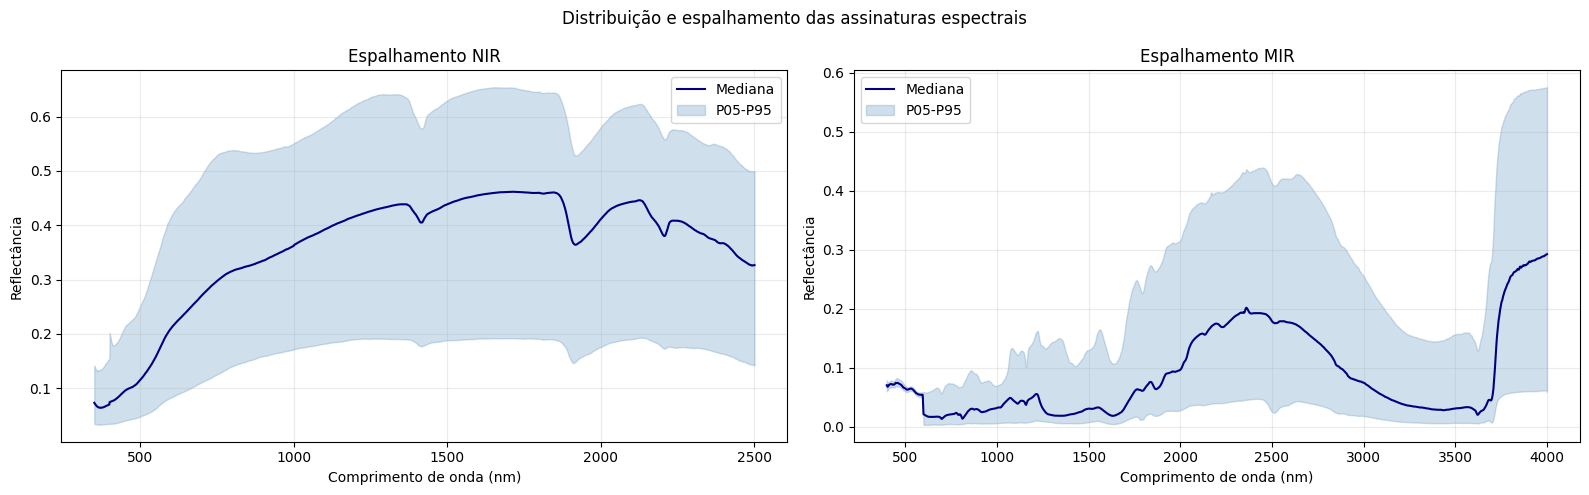

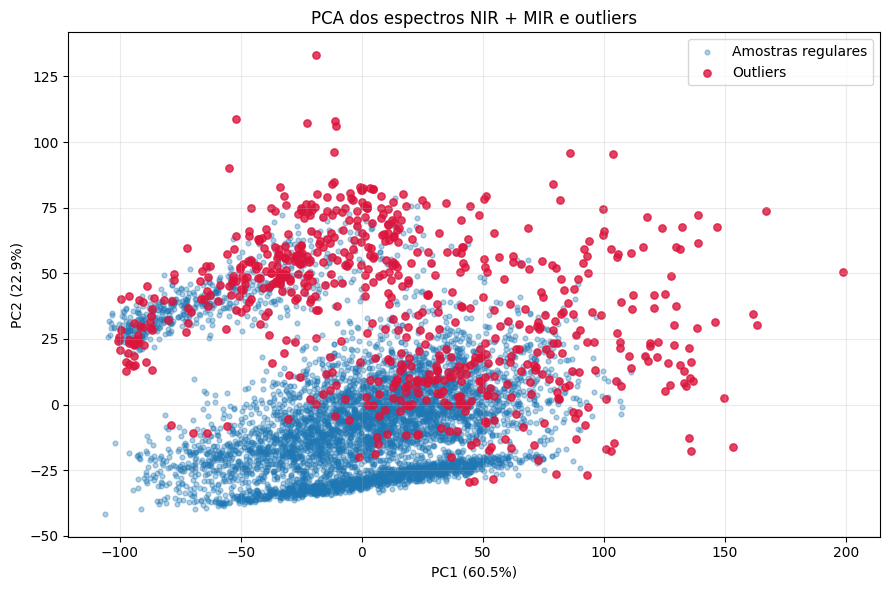


Amostras mais atípicas:


,ID_Unico,outlier,outlier_score,PC1,PC2
0,75481,True,-0.213045,103.780725,95.301485
1,74476,True,-0.208994,138.998507,72.088079
2,76263,True,-0.208862,117.757689,71.457042
3,75378,True,-0.201972,167.212742,73.570193
4,76262,True,-0.200872,99.646309,74.355600
5,75009,True,-0.192879,198.871540,50.596019
6,75492,True,-0.188134,132.438735,67.568351
7,77358,True,-0.186943,116.337624,60.019016
8,76340,True,-0.184282,146.960918,67.539883
9,76343,True,-0.178726,138.845987,61.699711


Interpretação: a faixa P05-P95 mostra a variação normal das assinaturas. Os outliers devem ser inspecionados antes da modelagem, mas não devem ser removidos automaticamente sem confirmar erro instrumental, amostra incomum ou condição agronômica real.


In [6]:
# Análise exploratória: espalhamento espectral, PCA e detecção de outliers
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

if "X_raw" not in globals() or "df_valid" not in globals():
    raise NameError("Execute primeiro a célula de fusão NIR+MIR.")

exploratory_matrix = X_raw.copy()
exploratory_matrix = exploratory_matrix.apply(pd.to_numeric, errors="coerce")
exploratory_matrix = exploratory_matrix.fillna(exploratory_matrix.median()).fillna(0.0)

# Remove bandas sem variação, pois não contribuem para PCA nem para outliers.
variable_band_mask = exploratory_matrix.std(axis=0) > 1e-12
exploratory_matrix = exploratory_matrix.loc[:, variable_band_mask]

# Escalonamento por banda para que NIR e MIR contribuam de forma comparável.
exploratory_scaler = StandardScaler()
exploratory_scaled = exploratory_scaler.fit_transform(exploratory_matrix)

# PCA para visualizar a estrutura global dos espectros.
n_pca = min(10, exploratory_scaled.shape[0] - 1, exploratory_scaled.shape[1])
pca_exploratory = PCA(n_components=n_pca, random_state=42)
pca_scores = pca_exploratory.fit_transform(exploratory_scaled)
explained_variance = pca_exploratory.explained_variance_ratio_

# Isolation Forest identifica amostras espectralmente atípicas no espaço PCA.
isolation_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1,
)
outlier_labels = isolation_forest.fit_predict(pca_scores[:, :min(10, n_pca)])
outlier_scores = isolation_forest.decision_function(pca_scores[:, :min(10, n_pca)])
outlier_mask = outlier_labels == -1

exploratory_results = pd.DataFrame({
    "ID_Unico": df_valid["ID_Unico"].to_numpy(),
    "outlier": outlier_mask,
    "outlier_score": outlier_scores,
    "PC1": pca_scores[:, 0],
    "PC2": pca_scores[:, 1],
})

print("ANÁLISE EXPLORATÓRIA NIR + MIR")
print("=" * 38)
print(f"Amostras analisadas: {exploratory_matrix.shape[0]}")
print(f"Bandas variáveis: {exploratory_matrix.shape[1]}")
print(f"Variância explicada por PC1: {explained_variance[0]:.2%}")
print(f"Variância explicada por PC2: {explained_variance[1]:.2%}")
print(f"Variância acumulada em PC1-PC2: {explained_variance[:2].sum():.2%}")
print(f"Outliers detectados: {outlier_mask.sum()} ({outlier_mask.mean():.2%})")

# Estatísticas de espalhamento por banda: mediana e intervalo central de 5%-95%.
spread_summary = pd.DataFrame({
    "band": exploratory_matrix.columns,
    "mean": exploratory_matrix.mean(axis=0).to_numpy(),
    "std": exploratory_matrix.std(axis=0).to_numpy(),
    "p05": exploratory_matrix.quantile(0.05, axis=0).to_numpy(),
    "median": exploratory_matrix.quantile(0.50, axis=0).to_numpy(),
    "p95": exploratory_matrix.quantile(0.95, axis=0).to_numpy(),
})
print("\nMaior espalhamento espectral por desvio-padrão:")
display(spread_summary.sort_values("std", ascending=False).head(10).round(6))

# Separa os sensores para preservar suas escalas e faixas espectrais originais.
def sensor_wavelengths(columns, prefix):
    selected = [column for column in columns if str(column).startswith(prefix)]
    values = []
    for column in selected:
        text = str(column).replace(prefix, "").replace(",", ".")
        try:
            values.append((column, float(text)))
        except ValueError:
            continue
    return sorted(values, key=lambda item: item[1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for axis, prefix, title in zip(axes, ("NIR_", "MIR_"), ("Espalhamento NIR", "Espalhamento MIR")):
    sensor_bands = sensor_wavelengths(exploratory_matrix.columns, prefix)
    if not sensor_bands:
        axis.set_visible(False)
        continue
    sensor_columns = [item[0] for item in sensor_bands]
    sensor_wavelength = np.array([item[1] for item in sensor_bands])
    sensor_spread = spread_summary.set_index("band").loc[sensor_columns]
    axis.plot(sensor_wavelength, sensor_spread["median"], color="navy", label="Mediana")
    axis.fill_between(
        sensor_wavelength,
        sensor_spread["p05"],
        sensor_spread["p95"],
        color="steelblue",
        alpha=0.25,
        label="P05-P95",
    )
    axis.set_title(title)
    axis.set_xlabel("Comprimento de onda (nm)")
    axis.set_ylabel("Reflectância")
    axis.grid(alpha=0.25)
    axis.legend()
plt.suptitle("Distribuição e espalhamento das assinaturas espectrais")
plt.tight_layout()
plt.show()

# PCA e outliers: pontos vermelhos são amostras espectralmente atípicas.
plt.figure(figsize=(9, 6))
plt.scatter(
    exploratory_results.loc[~outlier_mask, "PC1"],
    exploratory_results.loc[~outlier_mask, "PC2"],
    s=12,
    alpha=0.35,
    label="Amostras regulares",
)
plt.scatter(
    exploratory_results.loc[outlier_mask, "PC1"],
    exploratory_results.loc[outlier_mask, "PC2"],
    s=28,
    color="crimson",
    alpha=0.8,
    label="Outliers",
)
plt.xlabel(f"PC1 ({explained_variance[0]:.1%})")
plt.ylabel(f"PC2 ({explained_variance[1]:.1%})")
plt.title("PCA dos espectros NIR + MIR e outliers")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("\nAmostras mais atípicas:")
display(
    exploratory_results.sort_values("outlier_score").head(15).reset_index(drop=True).round(6)
)
print(
    "Interpretação: a faixa P05-P95 mostra a variação normal das assinaturas. "
    "Os outliers devem ser inspecionados antes da modelagem, mas não devem ser removidos "
    "automaticamente sem confirmar erro instrumental, amostra incomum ou condição agronômica real."
)


EDA COMPLETA NIR + MIR
Amostras usadas: 6230
Bandas totais: 3052
PCA PC1 + PC2: 84.63%
Clusters gerados: 4
Ruído RMSE médio: 0.000681
SNR proxy mediano: 274.506
Carbono R2: 0.7953
Carbono RMSE: 68.7369 g/kg
Carbono MAE: 47.2563 g/kg

Carbono por cluster:


,cluster,samples,carbon_mean_gkg,carbon_median_gkg,carbon_std_gkg
0,0,257,37.8668,7.0000,104.3213
1,1,607,110.6185,18.2135,166.3605
2,2,873,23.9496,14.8000,38.0866
3,3,1012,116.2277,14.5882,176.8712



Regiões minerais candidatas:


,region,start_nm,end_nm,mean_signal,min_signal,max_signal
0,OH / água estrutural,1350,1450,0.0334,0.0324,0.0360
1,Água / OH combinado,1850,1950,0.1039,0.0906,0.1190
2,Argilominerais / OH,2150,2350,0.1912,0.1761,0.2081
3,Carbonatos / combinações,2450,2550,0.1955,0.1869,0.2072
4,Carbonatos / CO3,3300,3700,0.0509,0.0417,0.1003



Amostras com maior ruído:


,noise_mean,noise_std,noise_rmse,signal_std,snr_proxy
1877,-0.000000,0.003078,0.003078,0.184654,59.985970
5719,-0.000000,0.002758,0.002758,0.171545,62.203352
5606,-0.000001,0.002636,0.002636,0.180706,68.560000
5607,0.000001,0.002486,0.002486,0.169407,68.134372
5735,-0.000000,0.002452,0.002452,0.156449,63.804530
5520,-0.000001,0.002373,0.002373,0.181973,76.697342
5604,0.000000,0.002365,0.002365,0.134744,56.979175
5733,-0.000000,0.002335,0.002335,0.191116,81.851335
5717,-0.000001,0.002328,0.002328,0.142239,61.106691
475,-0.000002,0.002310,0.002310,0.095261,41.239426


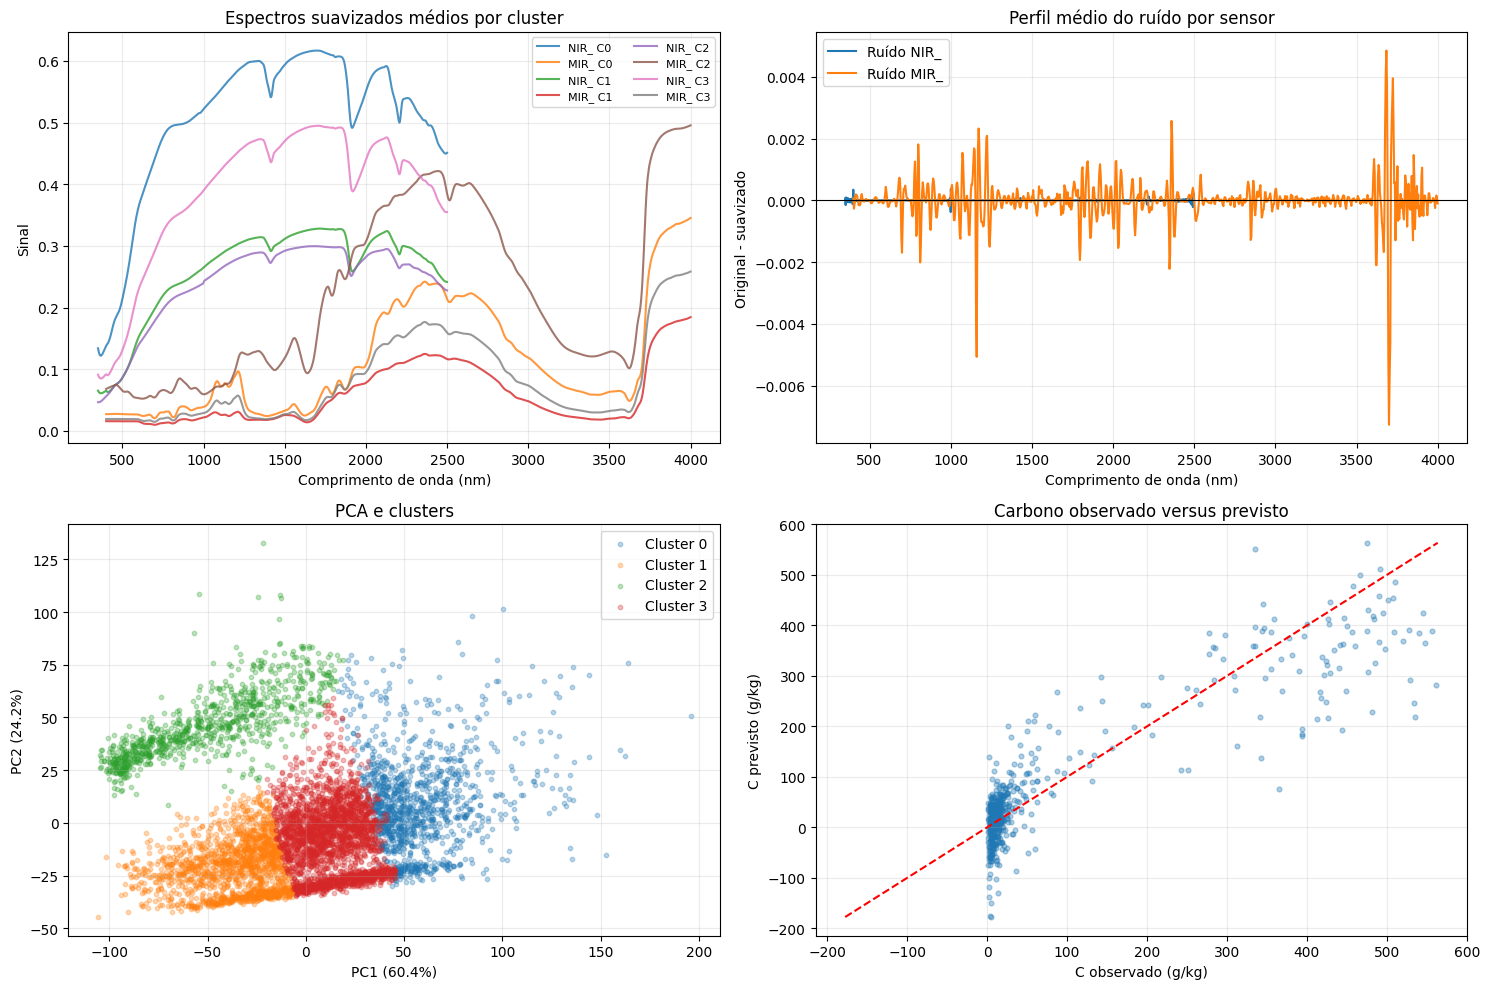

Interpretação: clusters resumem padrões de forma espectral; o ruído é a diferença entre o sinal original e o suavizado por linha. As regiões minerais são candidatas para triagem, não uma identificação química definitiva.


In [8]:
# EDA final: clusters, ruído Savitzky-Golay, minerais e comportamento do carbono
from scipy.signal import savgol_filter
from sklearn.cluster import KMeans
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if "X_raw" not in globals() or "df_valid" not in globals():
    raise NameError("Execute primeiro a célula de fusão NIR+MIR.")


def smooth_sensor(frame, prefix):
    ordered = []
    for column in frame.columns:
        text = str(column)
        if text.startswith(prefix):
            try:
                ordered.append((column, float(text.replace(prefix, ""))))
            except ValueError:
                pass
    ordered.sort(key=lambda item: item[1])
    columns = [item[0] for item in ordered]
    wavelengths = np.array([item[1] for item in ordered], dtype=float)
    matrix = np.array(frame[columns], dtype=float, copy=True)
    matrix[~np.isfinite(matrix)] = np.nan
    for row_index in range(matrix.shape[0]):
        row = matrix[row_index]
        valid = np.isfinite(row)
        if valid.sum() == 0:
            row[:] = 0.0
        elif valid.sum() == 1:
            row[:] = row[valid][0]
        else:
            row[:] = np.interp(np.arange(row.size), np.flatnonzero(valid), row[valid])
    window = min(15, matrix.shape[1])
    if window % 2 == 0:
        window -= 1
    smooth = matrix if window < 5 else savgol_filter(matrix, window_length=window, polyorder=2, axis=1)
    return wavelengths, smooth, matrix - smooth

sensor_blocks = {}
for prefix in ("NIR_", "MIR_"):
    if any(str(column).startswith(prefix) for column in X_raw.columns):
        sensor_blocks[prefix] = smooth_sensor(X_raw, prefix)
if not sensor_blocks:
    raise ValueError("Nenhum bloco espectral NIR ou MIR foi encontrado.")

smoothed_matrix = np.hstack([sensor_blocks[prefix][1] for prefix in ("NIR_", "MIR_") if prefix in sensor_blocks])
noise_matrix = np.hstack([sensor_blocks[prefix][2] for prefix in ("NIR_", "MIR_") if prefix in sensor_blocks])
noise_profile = pd.DataFrame({
    "noise_mean": noise_matrix.mean(axis=1),
    "noise_std": noise_matrix.std(axis=1),
    "noise_rmse": np.sqrt(np.mean(noise_matrix ** 2, axis=1)),
    "signal_std": smoothed_matrix.std(axis=1),
})
noise_profile["snr_proxy"] = noise_profile["signal_std"] / np.maximum(noise_profile["noise_std"], 1e-12)

# Cluster primeiro: PCA e K-means em todas as amostras NIR+MIR.
scaled_matrix = StandardScaler().fit_transform(smoothed_matrix)
pca_clusters = PCA(n_components=min(10, scaled_matrix.shape[0] - 1, scaled_matrix.shape[1]), random_state=42)
pca_scores_clusters = pca_clusters.fit_transform(scaled_matrix)
cluster_model = KMeans(n_clusters=4, n_init=10, random_state=42)
cluster_labels = cluster_model.fit_predict(pca_scores_clusters)

# Predição do comportamento do carbono usando scores PCA.
carbon_values = pd.to_numeric(df_valid["C_gkg"], errors="coerce").to_numpy(dtype=float)
carbon_indices = np.flatnonzero(np.isfinite(carbon_values))
train_index, test_index = train_test_split(carbon_indices, test_size=0.20, random_state=42)
carbon_model = PLSRegression(n_components=min(5, pca_scores_clusters.shape[1], len(train_index) - 1), scale=True)
carbon_model.fit(pca_scores_clusters[train_index], carbon_values[train_index])
carbon_prediction = carbon_model.predict(pca_scores_clusters[test_index]).ravel()
carbon_metrics = {
    "R2": r2_score(carbon_values[test_index], carbon_prediction),
    "RMSE": np.sqrt(mean_squared_error(carbon_values[test_index], carbon_prediction)),
    "MAE": mean_absolute_error(carbon_values[test_index], carbon_prediction),
}

cluster_carbon = pd.DataFrame({"cluster": cluster_labels[carbon_indices], "C_gkg": carbon_values[carbon_indices]}).groupby("cluster").agg(
    samples=("C_gkg", "size"),
    carbon_mean_gkg=("C_gkg", "mean"),
    carbon_median_gkg=("C_gkg", "median"),
    carbon_std_gkg=("C_gkg", "std"),
).reset_index()

# Regiões MIR candidatas para triagem mineralógica.
mir_wavelengths, mir_smooth, _ = sensor_blocks.get("MIR_", (np.array([]), np.empty((len(smoothed_matrix), 0)), None))
regions = {
    "OH / água estrutural": (1350, 1450),
    "Água / OH combinado": (1850, 1950),
    "Argilominerais / OH": (2150, 2350),
    "Carbonatos / combinações": (2450, 2550),
    "Carbonatos / CO3": (3300, 3700),
}
mineral_rows = []
if mir_wavelengths.size:
    mean_mir = mir_smooth.mean(axis=0)
    for name, (start_nm, end_nm) in regions.items():
        region_mask = (mir_wavelengths >= start_nm) & (mir_wavelengths <= end_nm)
        if region_mask.any():
            mineral_rows.append({"region": name, "start_nm": start_nm, "end_nm": end_nm, "mean_signal": mean_mir[region_mask].mean(), "min_signal": mean_mir[region_mask].min(), "max_signal": mean_mir[region_mask].max()})
mineral_summary = pd.DataFrame(mineral_rows)

print("EDA COMPLETA NIR + MIR")
print("=" * 28)
print(f"Amostras usadas: {smoothed_matrix.shape[0]}")
print(f"Bandas totais: {smoothed_matrix.shape[1]}")
print(f"PCA PC1 + PC2: {pca_clusters.explained_variance_ratio_[:2].sum():.2%}")
print(f"Clusters gerados: {len(np.unique(cluster_labels))}")
print(f"Ruído RMSE médio: {noise_profile['noise_rmse'].mean():.6f}")
print(f"SNR proxy mediano: {noise_profile['snr_proxy'].median():.3f}")
print(f"Carbono R2: {carbon_metrics['R2']:.4f}")
print(f"Carbono RMSE: {carbon_metrics['RMSE']:.4f} g/kg")
print(f"Carbono MAE: {carbon_metrics['MAE']:.4f} g/kg")
print("\nCarbono por cluster:")
display(cluster_carbon.round(4))
print("\nRegiões minerais candidatas:")
display(mineral_summary.round(4))
print("\nAmostras com maior ruído:")
display(noise_profile.sort_values("noise_rmse", ascending=False).head(10).round(6))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for cluster_id in np.unique(cluster_labels):
    mask = cluster_labels == cluster_id
    for prefix, (sensor_wavelengths, sensor_smooth, _) in sensor_blocks.items():
        axes[0, 0].plot(sensor_wavelengths, sensor_smooth[mask].mean(axis=0), alpha=0.8, label=f"{prefix} C{cluster_id}")
axes[0, 0].set_title("Espectros suavizados médios por cluster")
axes[0, 0].set_xlabel("Comprimento de onda (nm)")
axes[0, 0].set_ylabel("Sinal")
axes[0, 0].legend(ncol=2, fontsize=8)
axes[0, 0].grid(alpha=0.25)

for prefix, (_, _, noise_values) in sensor_blocks.items():
    axes[0, 1].plot(sensor_blocks[prefix][0], noise_values.mean(axis=0), label=f"Ruído {prefix}")
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("Perfil médio do ruído por sensor")
axes[0, 1].set_xlabel("Comprimento de onda (nm)")
axes[0, 1].set_ylabel("Original - suavizado")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

for cluster_id in np.unique(cluster_labels):
    mask = cluster_labels == cluster_id
    axes[1, 0].scatter(pca_scores_clusters[mask, 0], pca_scores_clusters[mask, 1], s=10, alpha=0.3, label=f"Cluster {cluster_id}")
axes[1, 0].set_title("PCA e clusters")
axes[1, 0].set_xlabel(f"PC1 ({pca_clusters.explained_variance_ratio_[0]:.1%})")
axes[1, 0].set_ylabel(f"PC2 ({pca_clusters.explained_variance_ratio_[1]:.1%})")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

axes[1, 1].scatter(carbon_values[test_index], carbon_prediction, s=12, alpha=0.35)
plot_min = min(carbon_values[test_index].min(), carbon_prediction.min())
plot_max = max(carbon_values[test_index].max(), carbon_prediction.max())
axes[1, 1].plot([plot_min, plot_max], [plot_min, plot_max], "r--")
axes[1, 1].set_title("Carbono observado versus previsto")
axes[1, 1].set_xlabel("C observado (g/kg)")
axes[1, 1].set_ylabel("C previsto (g/kg)")
axes[1, 1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Interpretação: clusters resumem padrões de forma espectral; o ruído é a diferença entre o sinal original e o suavizado por linha. As regiões minerais são candidatas para triagem, não uma identificação química definitiva.")


In [9]:
# Interpretação da EDA espectral NIR + MIR
if "cluster_carbon" not in globals() or "carbon_metrics" not in globals():
    print("Execute primeiro a célula de EDA NIR+MIR.")
else:
    highest_carbon_cluster = cluster_carbon.loc[cluster_carbon["carbon_mean_gkg"].idxmax()]
    lowest_carbon_cluster = cluster_carbon.loc[cluster_carbon["carbon_mean_gkg"].idxmin()]
    noise_mean = noise_profile["noise_rmse"].mean()
    noise_median = noise_profile["noise_rmse"].median()
    pca_variance = pca_clusters.explained_variance_ratio_[:2].sum()

    print("INTERPRETAÇÃO DA EDA NIR + MIR")
    print("=" * 38)
    print(
        f"A PCA resume {pca_variance:.2%} da variabilidade espectral nas duas primeiras "
        "componentes. Isso indica que a projeção PC1-PC2 é adequada para visualizar "
        "a estrutura geral dos espectros e os quatro clusters."
    )
    print(
        f"O cluster {int(highest_carbon_cluster['cluster'])} apresentou o maior carbono médio "
        f"({highest_carbon_cluster['carbon_mean_gkg']:.2f} g/kg), enquanto o cluster "
        f"{int(lowest_carbon_cluster['cluster'])} apresentou o menor "
        f"({lowest_carbon_cluster['carbon_mean_gkg']:.2f} g/kg)."
    )
    print(
        f"O ruído residual médio após Savitzky-Golay foi {noise_mean:.6f} "
        f"(mediana={noise_median:.6f}). O SNR proxy mediano foi "
        f"{noise_profile['snr_proxy'].median():.2f}, sugerindo sinal espectral muito maior "
        "que o ruído residual nesta base."
    )
    print(
        f"Para o carbono, o modelo PLS nos scores PCA alcançou R2={carbon_metrics['R2']:.4f}, "
        f"RMSE={carbon_metrics['RMSE']:.4f} g/kg e MAE={carbon_metrics['MAE']:.4f} g/kg."
    )

    print("\nLeitura mineralógica:")
    print(
        "As regiões OH/água, argilominerais/OH e carbonatos foram marcadas como "
        "regiões candidatas de interesse. Elas orientam a inspeção espectral, mas não "
        "constituem identificação mineral definitiva sem padrões de referência, "
        "bandas diagnósticas e confirmação laboratorial."
    )
    if "mineral_summary" in globals() and not mineral_summary.empty:
        strongest_region = mineral_summary.loc[
            mineral_summary["max_signal"].idxmax()
        ]
        print(
            f"Na média espectral, a maior amplitude entre as regiões avaliadas ocorreu em "
            f"{strongest_region['region']} ({strongest_region['start_nm']:.0f}-"
            f"{strongest_region['end_nm']:.0f} nm)."
        )

    print("\nConclusão:")
    print(
        "Os clusters podem ser usados como grupos exploratórios de assinatura espectral "
        "e para comparar tendências de carbono. Não se deve remover amostras apenas por "
        "pertencerem a um cluster extremo ou apresentarem maior ruído; é necessário "
        "verificar a qualidade instrumental e o contexto agronômico."
    )


INTERPRETAÇÃO DA EDA NIR + MIR
A PCA resume 84.63% da variabilidade espectral nas duas primeiras componentes. Isso indica que a projeção PC1-PC2 é adequada para visualizar a estrutura geral dos espectros e os quatro clusters.
O cluster 3 apresentou o maior carbono médio (116.23 g/kg), enquanto o cluster 2 apresentou o menor (23.95 g/kg).
O ruído residual médio após Savitzky-Golay foi 0.000681 (mediana=0.000634). O SNR proxy mediano foi 274.51, sugerindo sinal espectral muito maior que o ruído residual nesta base.
Para o carbono, o modelo PLS nos scores PCA alcançou R2=0.7953, RMSE=68.7369 g/kg e MAE=47.2563 g/kg.

Leitura mineralógica:
As regiões OH/água, argilominerais/OH e carbonatos foram marcadas como regiões candidatas de interesse. Elas orientam a inspeção espectral, mas não constituem identificação mineral definitiva sem padrões de referência, bandas diagnósticas e confirmação laboratorial.
Na média espectral, a maior amplitude entre as regiões avaliadas ocorreu em Argilominerai




The interpretation cell was added and executed successfully.

Key findings:

- PCA PC1 + PC2 explain `84.63%` of spectral variability.
- Cluster `3` has the highest mean carbon:
  - `116.23 g/kg`
- Cluster `2` has the lowest mean carbon:
  - `23.95 g/kg`
- Mean residual noise after Savitzky-Golay:
  - `0.000681`
- Median SNR proxy:
  - `274.51`
- Carbon prediction:
  - $R^2 = 0.7953$
  - RMSE: `68.7369 g/kg`
  - MAE: `47.2563 g/kg`

The strongest candidate mineral region was **Argilominerals/OH, 2150–2350 nm**. The cell also clarifies that these regions are screening candidates and require laboratory or reference-spectrum confirmation before definitive mineral identification.

